In [1]:
import torch 
import matplotlib.pyplot as plt
import numpy as np

from AIce.functions import testloader,redim,Static0Danalysis
from AIce.models import staticNN
from AIce.plotting import RecallPrecisionStatic

In [2]:
# Ensuring the right inputs and target
weight='./weights/staticNN_10inputs_20E_0.001lr_31-15h_31m_44s.pt'
with open(f'{weight[:-3]}.txt', 'r') as f:
    for i in range(2):
        f.readline()
    splits=f.read().split(':')
    lst=splits[1].strip()
    lst=lst.strip('[]').strip()
    lst=lst.split(',')
    lst=[x.strip()[1:-1] for x in lst]
    print(lst)
    
inputlist=lst

target='static'

# Load the test_data_following 
datapd,_,_,means,stds,maxes,labels= testloader('../data/DRIFT_DATA_TEST.csv', inputlist=inputlist,target=target,trainingset_loaded=False,training_file='../data/DRIFT_DATA_TRAIN.csv')

# Loading the model
static256=staticNN(len(labels[1]))
static256.load_state_dict(torch.load(weight, weights_only=True))# loads the weights onto the model
static256.eval()  # if you're doing inference, not continuing training

inputs=datapd.drop([target], axis=1).values

out=torch.sigmoid(static256(torch.tensor(inputs, dtype = torch.float32))).to('cpu').detach().numpy()

datapd['output']=out

# redim
datapd[inputlist]=redim(datapd[inputlist],
                        means=means,
                        stds=stds,
                        maxes=maxes)

['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'x_EASE', 'y_EASE', 'bath', 'sin', 'cos', 'windnorm']
Bath size is the full test set
Target is Staticity with threshold 0.001
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Wind components (u/v_ERA5) normalized by z-score


C:\Users\testd\OneDrive\Bureau\McGilles\Code\RechercheMsc\src\AIce\functions.py:394: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datapd[i]=datapd[i]*stds[i]+means[i]
C:\Users\testd\OneDrive\Bureau\McGilles\Code\RechercheMsc\src\AIce\functions.py:396: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datapd[i]*=maxes[i]


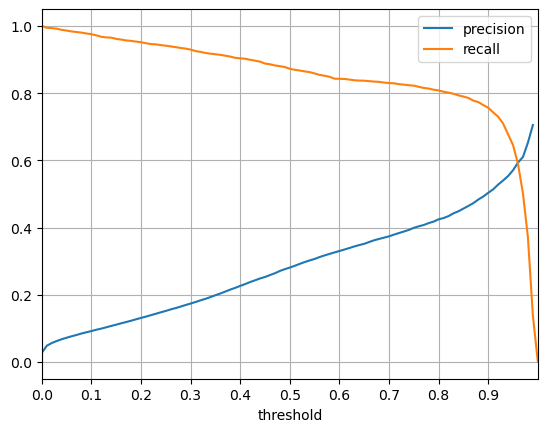

Precision means of the things I called static/moving, how many actually were?
Recall means how many of the real static/moving did I find?
Static Recall % 0.6453287197231834
Moving Recall % 0.9863840828352146
Static Precision % 0.5705544933078394
Moving Precision % 0.9900211745807677
Total Precision % 0.9770842915944286


In [3]:
RecallPrecisionStatic(datapd['static'],datapd['output'])

zeroD,true_false_pred=Static0Danalysis(datapd['static'],datapd['output'])


- 19 E; 
Good guess % tensor(87.8958)
Guessed moving wrong % tensor(12.0037)
Guess Static Wrong % tensor(15.7918)

- 19 E with weights 36;
Good guess % tensor(89.6638)
Falsely Static % tensor(10.1186)
Falsely moving % tensor(18.3274)
- 19 E with weight 64
Good guess % tensor(83.9590)
Guessed moving wrong % tensor(16.1047)
Guess Static Wrong % tensor(13.7011)

- 199 E;
Good guess % tensor(92.7514)
Falsely Static % tensor(7.1783)
Falsely moving % tensor(9.8310)

-500 E wiehgt, 64:
Good guess % tensor(93.5227)
Guessed moving wrong % tensor(6.3702)
Guess Static Wrong % tensor(10.4093)

-500 weight 147;
Good guess % tensor(90.8844)
Guessed moving wrong % tensor(9.1300)
Guess Static Wrong % tensor(8.5854)

- 874 E;
2248.0 4791.0
Good guess % tensor(96.2483)
Falsely Static % tensor(3.4674)
Falsely moving % tensor(14.1904)


Good guess % tensor(93.9143)
Guessed moving wrong % tensor(5.9377)
Guess Static Wrong % tensor(11.5214)

Precision means of the things I called static/moving, how many actually were?
Recall means how many of the real static/moving did I find?
Static Recall % 0.6453287197231834
Moving Recall % 0.9863840828352146
Static Precision % 0.5705544933078394
Moving Precision % 0.9900211745807677
Total Precision % 0.9770842915944286